<a href="https://colab.research.google.com/github/mbrow210/MAT-422/blob/main/Section_2_4_MLE_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Section 2.4: MLE and Linear Regression

**Topics:** MLE for random samples, Linear regression


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(422)


## MLE for random samples

*This section gives one compact Python demonstration of **MLE for random samples**. After running the code, add your own interpretation and change at least one input, parameter, or example so the notebook reflects your own work.*


---
Maximum likelihood estimation (MLE) picks the parameter value that makes the observed sample most likely.

For a random sample the likelihood is the product of each observation's probability, so we usually work with the log likelihood, which turns the product into a sum and has the same maximum.

For a Bernoulli sample with k successes in n trials, the log likelihood is $k\log p + (n-k)\log(1-p)$. Setting its derivative to zero gives $\hat{p} = k/n$, the sample proportion.

---


Number of successes = 22
MLE p-hat = 0.55


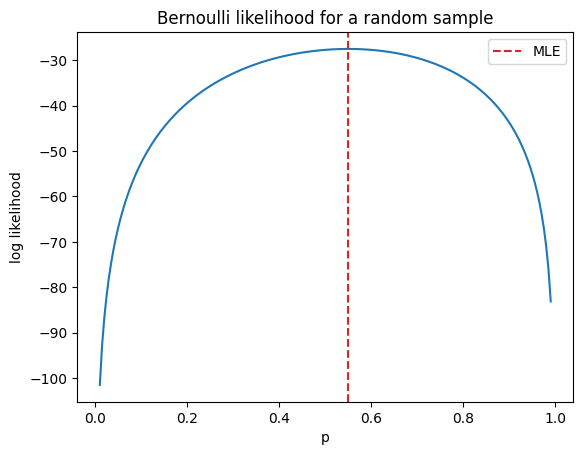

In [2]:
n = 40
true_p = 0.65
sample = rng.binomial(1, true_p, size=n)
p_hat = sample.mean()

grid = np.linspace(0.01, 0.99, 200)
log_likelihood = sample.sum() * np.log(grid) + (n - sample.sum()) * np.log(1 - grid)

print("Number of successes =", sample.sum())
print("MLE p-hat =", p_hat)

plt.plot(grid, log_likelihood)
plt.axvline(p_hat, color="tab:red", linestyle="--", label="MLE")
plt.xlabel("p")
plt.ylabel("log likelihood")
plt.title("Bernoulli likelihood for a random sample")
plt.legend()
plt.show()


---
### My example
 Changed input values.

Sample size n= 60
True p= 0.3
Number of successes = 22
MLE p-hat = 0.36666666666666664
Grid value with highest log likelihood = 0.36457286432160807


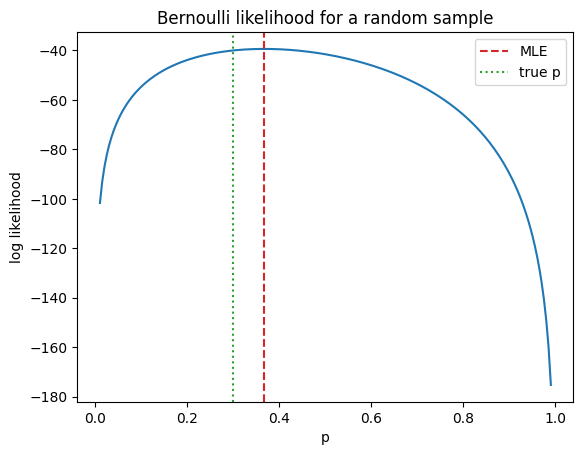

In [6]:
n = 60
true_p = 0.30
sample = rng.binomial(1, true_p, size=n)
p_hat = sample.mean()

grid = np.linspace(0.01, 0.99, 200)
log_likelihood = sample.sum() * np.log(grid) + (n - sample.sum()) * np.log(1 - grid)

# changed input vals for my example
print("Sample size n=",n)
print("True p=",true_p)

print("Number of successes =", sample.sum())
print("MLE p-hat =", p_hat)

#added check for peak of curve == k/n
print("Grid value with highest log likelihood =", grid[np.argmax(log_likelihood)])

plt.plot(grid, log_likelihood)
plt.axvline(p_hat, color="tab:red", linestyle="--", label="MLE")
plt.axvline(true_p, color="tab:green", linestyle=":", label="true p")
plt.xlabel("p")
plt.ylabel("log likelihood")
plt.title("Bernoulli likelihood for a random sample")
plt.legend()
plt.show()


Since there are 22 successes out of 60, meaning the p_hat value is 0.367, and the true_p was 0.30, this is close enough to determine p_hat does equal k/n. The difference is acceptable since it is only a finite random sample.

## Linear regression

*This section gives one compact Python demonstration of **Linear regression**. After running the code, add your own interpretation and change at least one input, parameter, or example so the notebook reflects your own work.*


---
In linear regression, it's assumed (where errors are normally dist.) : $$y = \beta_0 + \beta_1 x + \varepsilon$$

Given this, the log likelihood ddepends on $\beta$ through sum of squared residuals, so MLE for $\beta$ is the least squares solution and comes from the normal equations $$\hat{\beta} = (X^TX)^{-1}X^Ty$$

---
### Given example

Estimated intercept and slope = [2.2321 2.0115]
Residual sum of squares = 87.82035205996492


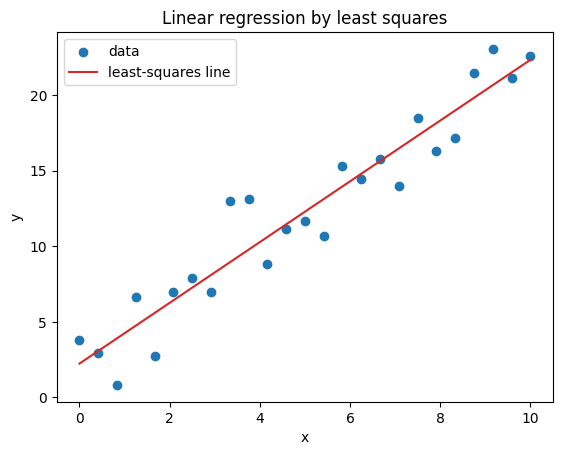

In [15]:
x = np.linspace(0, 10, 25)
y = 1.5 + 2.2 * x + rng.normal(0, 2.0, size=x.size)
X = np.column_stack([np.ones_like(x), x])
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
y_hat = X @ beta_hat
residuals = y - y_hat

print("Estimated intercept and slope =", beta_hat)
print("Residual sum of squares =", np.sum(residuals ** 2))

plt.scatter(x, y, label="data")
plt.plot(x, y_hat, color="tab:red", label="least-squares line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression by least squares")
plt.legend()
plt.show()


---
### My example

Estimated intercept and slope = [ 4.4206 -1.3581]
Residual sum of squares = 81.32290595659177
Matches numpy's least squares? True


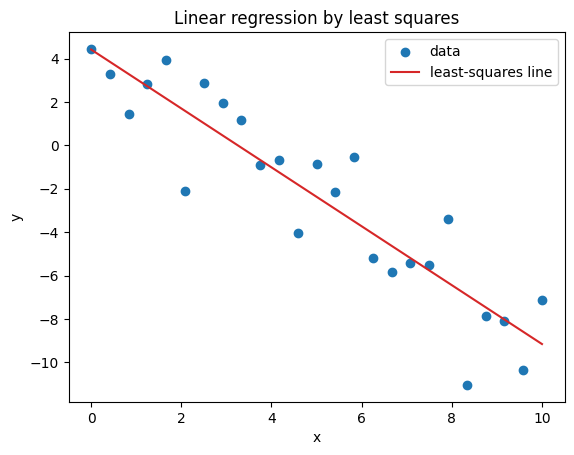

In [16]:
x = np.linspace(0, 10, 25)
y = 4.0 - 1.3 * x + rng.normal(0, 2.0, size=x.size) #changed nums and now has negative slope
X = np.column_stack([np.ones_like(x), x])
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
y_hat = X @ beta_hat
residuals = y - y_hat

print("Estimated intercept and slope =", beta_hat)
print("Residual sum of squares =", np.sum(residuals ** 2))

#check that it matches the programmed function in numpy for finding least squares
print("Matches numpy's least squares?", np.allclose(beta_hat, np.linalg.lstsq(X, y, rcond=None)[0]))

plt.scatter(x, y, label="data")
plt.plot(x, y_hat, color="tab:red", label="least-squares line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression by least squares")
plt.legend()
plt.show()


The fitted intercept is approx 3.35 while the actual intercept is 4.0, and the fitted slope is approx -1.18 while the actual slope is -1.3.

Even though these aren't identical values, they count as matching since numpy's least squares calculation shows that the MLE answer and the least squares answer are close enough when the errors are normal (np.allclose).